# imports

In [2]:
import numpy as np
import pandas as pd
import hypertools as hyp
import nibabel as nb
import nilearn as nl
import supereeg as se
import pickle
import os
import joblib
import cortex
from cortex import mni
import neurosynth as ns
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, ttest_1samp, ttest_ind, ttest_rel
import importlib.util as importer
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# set paths

In [3]:
annot_dir = '../../data/annotations_dfs/'
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings', 'k:1000')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings', 'k:1000')
pickle_dir = '../../data/pickles/'
braindata_dir = '../../data/brains/'
fig_dir = '../../figures/'
brainfig_dir = os.path.join(fig_dir,'brains/')

# load data

In [4]:
# dictionary of fit CountVectorizer and LatentDirichletAllocation models
with open(pickle_dir+'fit_models.p', 'rb') as f:
    models_dict = pickle.load(f)
    
brainweights = np.load(braindata_dir+'HuthModelWeights.npy')
mask = np.load(braindata_dir+'mask.npy')

away_from_topics = np.load(braindata_dir+'away_from_topic_vector.npy')
toward_topics = np.load(braindata_dir+'toward_topic_vector.npy')
    
#ns_dataset = ns.base.dataset.Dataset.load(pickle_dir+'neurosynth_dataset.p')

# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir, topdown=True):
    dirs[:] = [d for d in dirs if d not in ['vidwProp', 'vidwProp_recwProp']]
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))
        
# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

# episode-recall event mappings
event_mappings = dict()
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
        event_mappings[rectype] = pickle.load(f)
        
# session 1/session 2 psiturk ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)
    
# transform from pycortex space to MNI space
s1_to_mni = np.load(braindata_dir+'mni_xfm.npy')

# voxel activations for each topic dimension
episode_topic_voxweights = {ep : np.load(os.path.join(braindata_dir, ep, 'topic_voxelweights.npy'))
                            for ep in ['atlep1','atlep2','arrdev']}

# neurosynth dataset
ns_dataset = ns.base.dataset.Dataset.load(pickle_dir+'neurosynth_dataset.p')

# define some functions

In [5]:
def _z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

In [6]:
def _r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))

In [7]:
def corr_mean(rs, axis=0):
    """
    Function that calculates the mean of correlation coefficients,
    performing Fisher z-transformation and inverse z-transormation
    
    Parameters
    ----------
    rs: : list or ndarray
        Correlation values
    
    Returns
    ----------
    result : float
        mean of correlation values

    """
    return _z2r(np.nanmean([_r2z(r) for r in rs], axis=axis))

In [8]:
def standardize_brainspace(vol, xfm=s1_to_mni):
    mni_space = cortex.mni.transform_to_mni(vol, xfm)
    std_brain = se.helpers._std((2,2,2))
    res_mni = nl.image.resample_img(mni_space, target_affine=std_brain.affine, target_shape=std_brain.shape)
    return res_mni

# does content overlap with memory networks influence memorability?

### train a neurosynth decoder on he union of top words from neurosynth topics (v5-topics-50)

In [333]:
t9 = '''memory, working, wm, load, task, verbal, performance, maintenance, term, cognitive, parietal, short, 
frontal, delay, encoding, executive, prefrontal, high, capacity, spatial, long, network, delayed, updating, 
storage, items, manipulation, probe, functions, span, vwm, ltm, vstm, phase, stm, maintained, prospective, 
period, frontoparietal, retention'''.replace('\n','').split(', ')
t33 = '''memory, retrieval, encoding, hippocampus, recognition, hippocampal, episodic, items, words, temporal, 
memories, mtl, medial, successful, recall, subsequent, cortex, associative, recollection, item, test, semantic, 
word, context, prefrontal, pairs, source, studied, familiarity, associations, lobe, encoded, parahippocampal, 
formation, autobiographical, presented, suggest, posterior, correct, remembered'''.replace('\n','').split(', ')

tcustom = '''memory, encoding, hippocampus, hippocampal, retrieval, recognition, associative, events, memories,
subsequent, successful, associations, recall, episodic, formation, items, verbal, encoded, prefrontal, 
test, learning, remembered, task, parahippocampal, delay, studied'''.replace('\n','').split(', ')

features = list(set(t9+t33))

In [346]:
# memory_decoder = ns.analysis.decode.Decoder(ns_dataset, features=features)
# joblib.dump(memory_decoder, braindata_dir+'memory_decoder.joblib')
# memory_decoder = joblib.load(braindata_dir+'memory_decoder.joblib')
# memory_decoder = ns.analysis.decode.Decoder(ns_dataset, features=['memory'])
# memory_decoder = ns.analysis.decode.Decoder(ns_dataset, features=tcustom)
memory_decoder = ns.analysis.decode.Decoder(ns_dataset, features=t9)

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: Joint

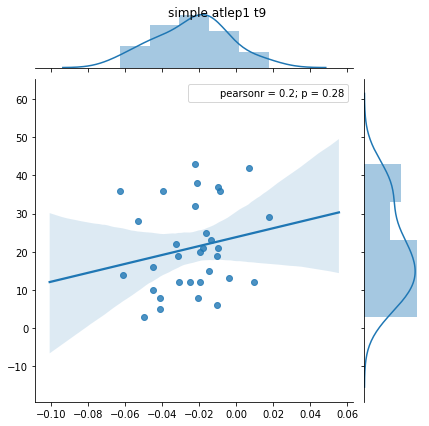

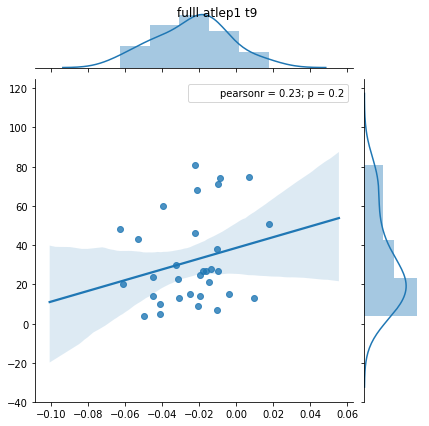

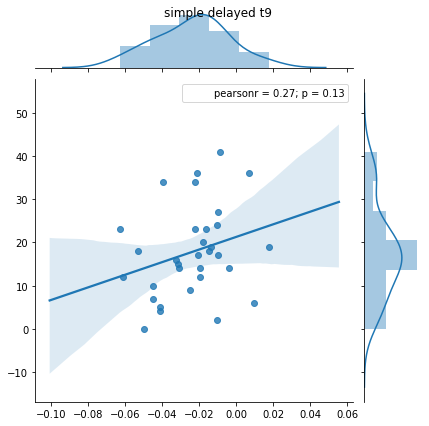

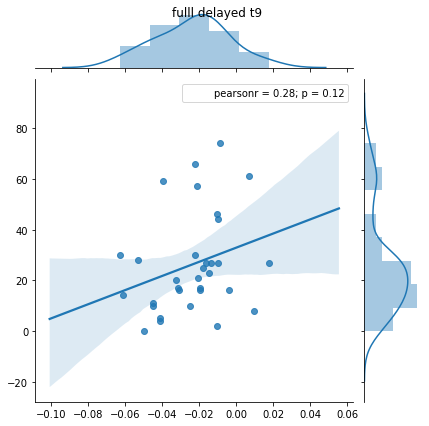

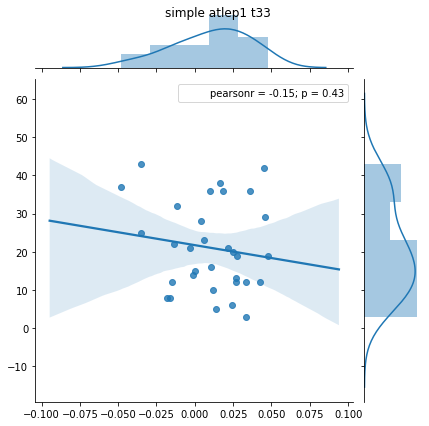

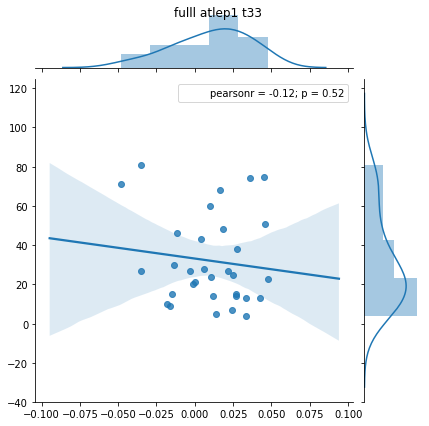

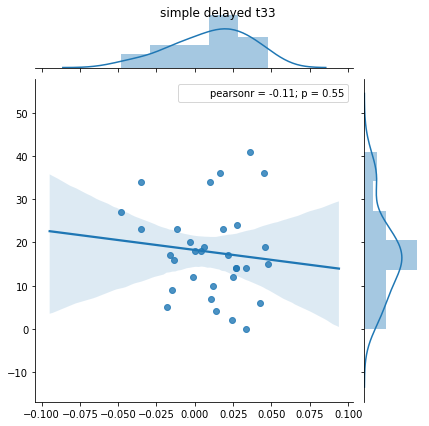

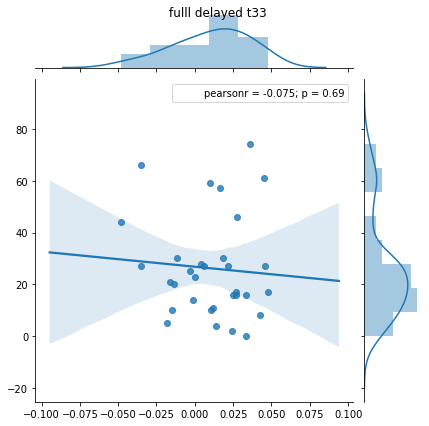

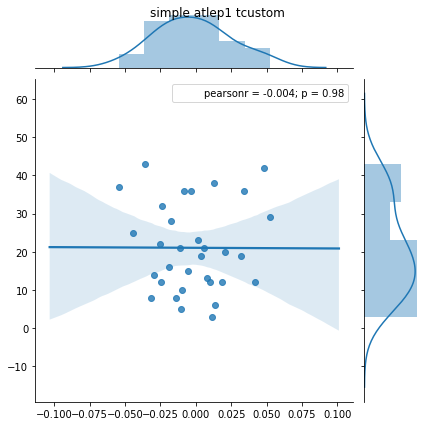

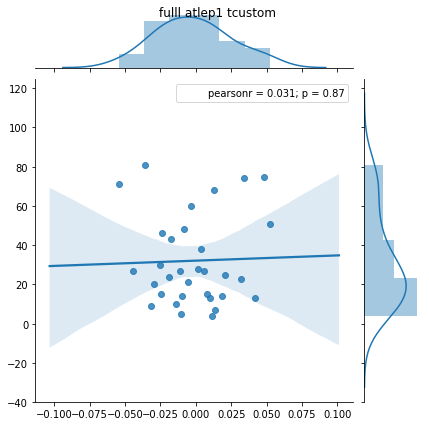

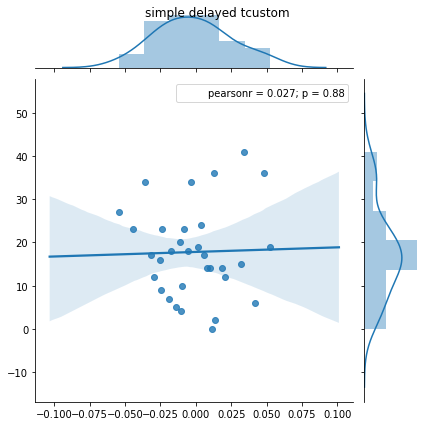

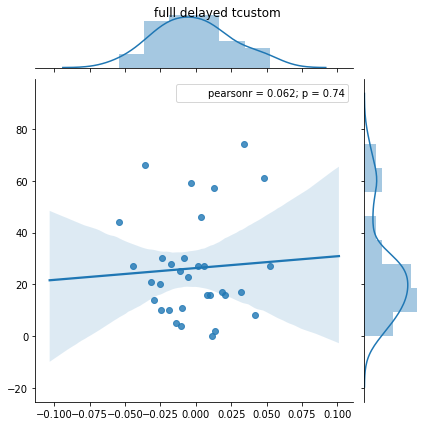

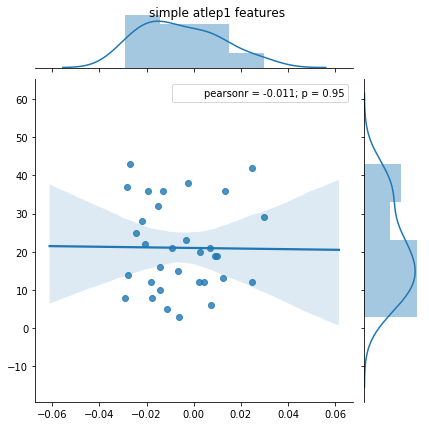

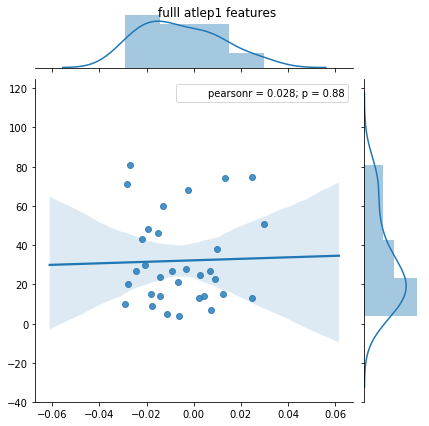

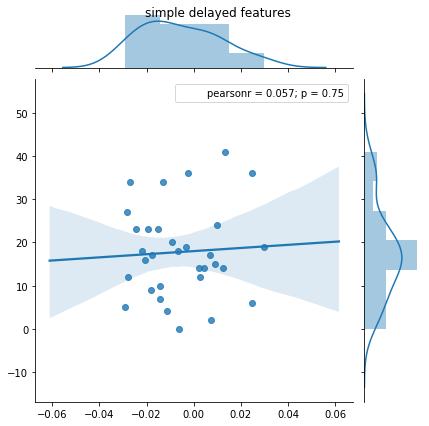

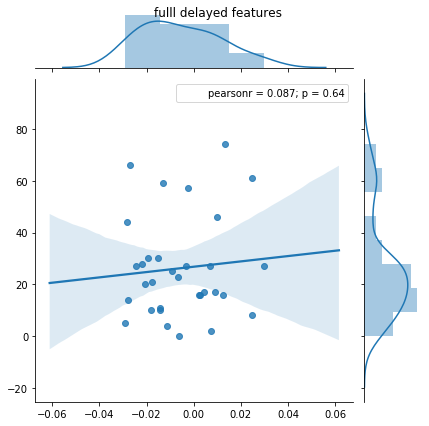

In [372]:
atl1_events = episode_events['atlep1']
atl1_topic_brainmaps = episode_topic_voxweights['atlep1']

for i, iname in zip([t9, t33, tcustom, features], ['t9', 't33', 'tcustom', 'features']):
    memory_decoder = ns.analysis.decode.Decoder(ns_dataset, features=i)
    
    for j in ['atlep1','delayed']:
        atl1_matches = event_mappings[j]
        memory_weights = np.zeros((atl1_events.shape[0],))
        memorability_simple = np.zeros((atl1_events.shape[0],))
        memorability_full = np.zeros((atl1_events.shape[0],))
    
        for ix, event in enumerate(atl1_events):
            event_brainmap = np.dot(event, atl1_topic_brainmaps)
            event_volume = cortex.Volume(event_brainmap, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
            event_brainmap_mni = standardize_brainspace(event_volume)

            decoded_event = memory_decoder.decode(np.expand_dims(ns_dataset.masker.mask(event_brainmap_mni), axis=1))

            if decoded_event.values.ravel().shape[0] > 1:
                memory_weights[ix] = corr_mean(decoded_event.values.ravel())
            else:
                memory_weights[ix] = decoded_event.values.ravel()[0]

            for tid, matches in atl1_matches:
                memorability_full[ix] += matches.tolist().count(ix)
                if ix in matches:
                    memorability_simple[ix] += 1
                    
        sns.jointplot(memory_weights, memorability_simple, kind='reg', stat_func=pearsonr)
        plt.suptitle('simple {0} {1}'.format(j, iname))
        sns.jointplot(memory_weights, memorability_full, kind='reg', stat_func=pearsonr)
        plt.suptitle('fulll {0} {1}'.format(j, iname))

# does content overlap with default mode network influence memorability?

### train a neurosynth decoder on he union of top words from neurosynth topics (v5-topics-50)

In [375]:
dmn_50 = '''network, state, resting, default, dmn, mode, intrinsic, fc, rest, cognitive, seed, control, 
independent, rs, attention, nodes, posterior, global, rsns, large, scale, local, spontaneous, executive, sn, 
salience, dorsal, pcc, identified, strength, cingulate, organization, fluctuations, inter, positive, 
relationship, states, graph, ec, hubs'''.replace('\n','').replace('\t','').split(', ')

dmn_100 = '''network, state, resting, default, dmn, mode, fc, intrinsic, rest, seed, cognitive, 
independent, rs, pcc, posterior, salience, rsns, sn, nodes, attention, strength, graph, scale, global, 
executive, hubs, inter, dorsal, organization, large, states, sensorimotor, identified, fcmri, positive, 
precuneus, centrality, provide, patterns, cingulate'''.replace('\n','').replace('\t','').split(', ')

dmn_200 = '''network, default, dmn, mode, state, resting, pcc, rest, cognitive, posterior, independent, 
intrinsic, attention, precuneus, dorsal, dan, control, executive, salience, seed, relationship, fpn, positive, 
cognition, states, anti, scale, nodes, goal, external, internal, smn, spontaneous, thoughts, mental, 
characterized, ecn, suggested, tpn, large'''.replace('\n','').replace('\t','').split(', ')

features = list(set(dmn_50+dmn_100+dmn_200))

In [341]:
# dmn_decoder = ns.analysis.decode.Decoder(ns_dataset, features=dmn_topics)
# joblib.dump(dmn_decoder, braindata_dir+'dmn_decoder.joblib')
# dmn_decoder = joblib.load(braindata_dir+'dmn_decoder.joblib')
# dmn_decoder = ns.analysis.decode.Decoder(ns_dataset, features=['default', 'mode','dmn','resting'])

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: Joint

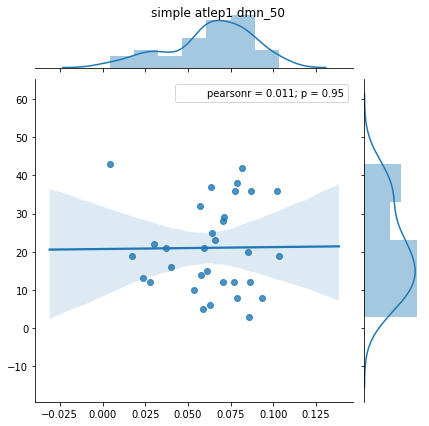

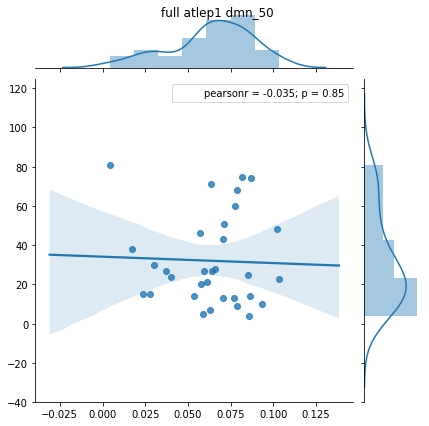

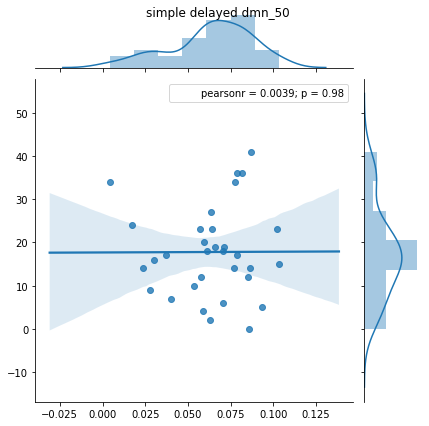

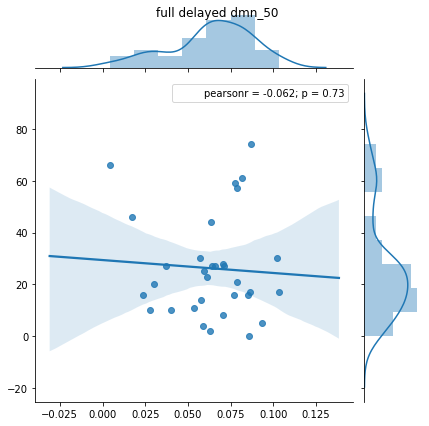

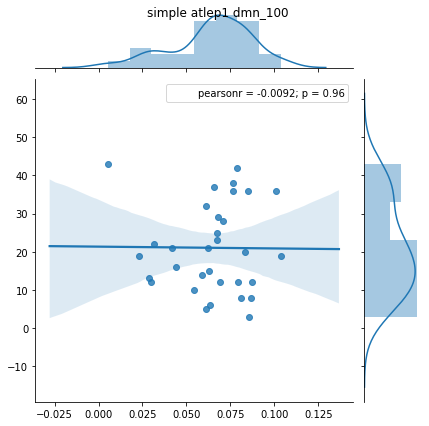

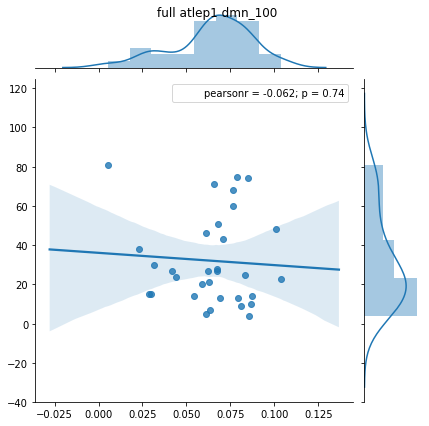

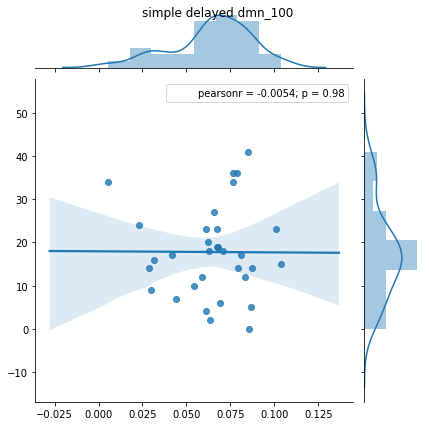

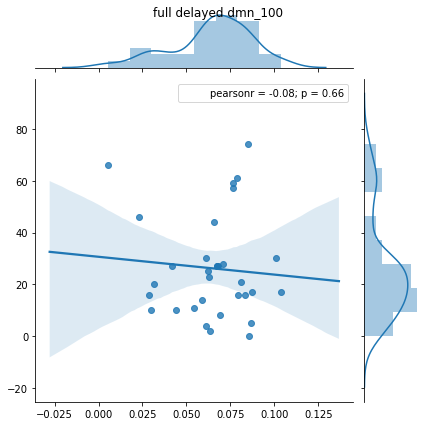

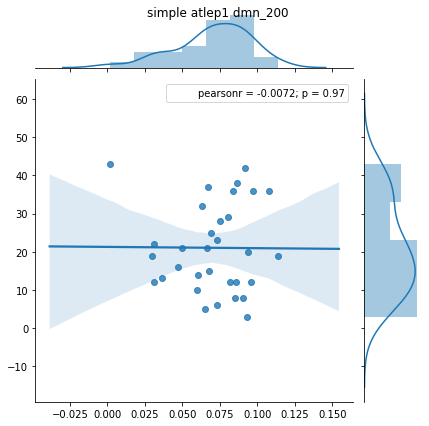

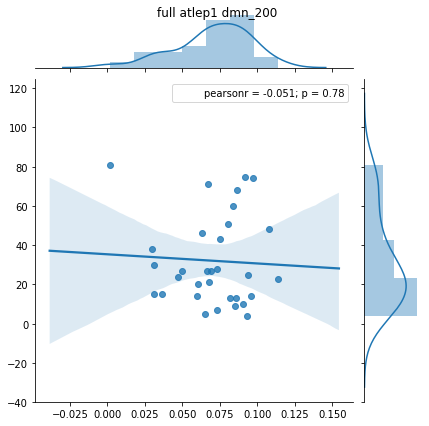

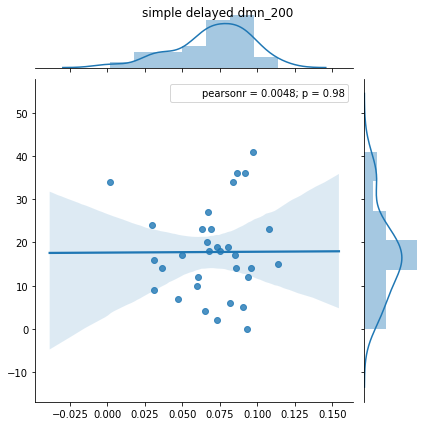

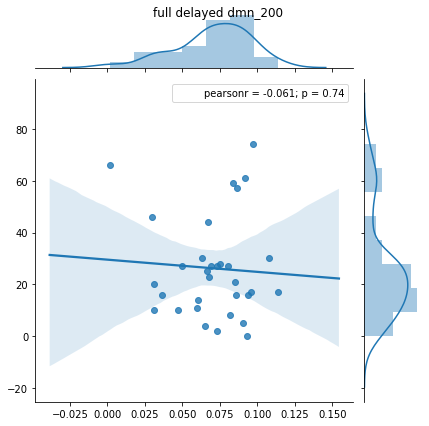

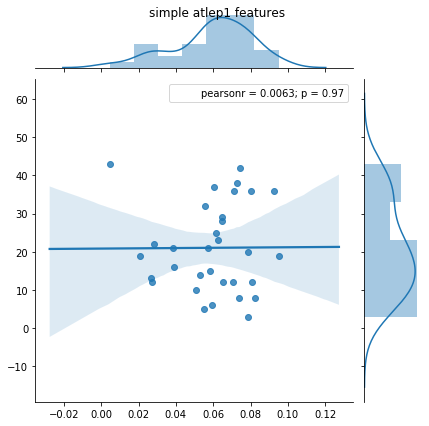

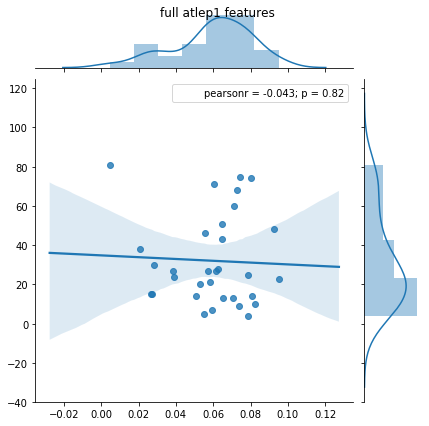

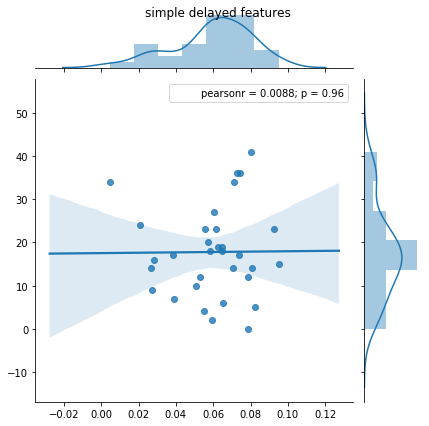

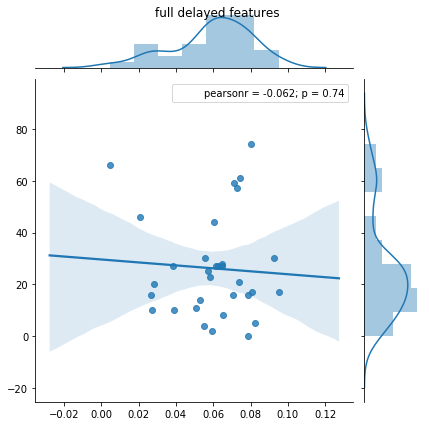

In [377]:
# atl1_events = episode_events['atlep1']
# atl1_topic_brainmaps = episode_topic_voxweights['atlep1']
# atl1_matches = event_mappings['delayed']

# for i, iname in zip([dmn_50, dmn_100, dmn_200, features], ['dmn_50', 'dmn_100', 'dmn_200', 'features']):
#     dmn_decoder = ns.analysis.decode.Decoder(ns_dataset, features=i)
    
#     for j in ['atlep1','delayed']:
#         atl1_matches = event_mappings[j]
#         memory_weights = np.zeros((atl1_events.shape[0],))
#         memorability_simple = np.zeros((atl1_events.shape[0],))
#         memorability_full = np.zeros((atl1_events.shape[0],))

#         for ix, event in enumerate(atl1_events):
#             event_brainmap = np.dot(event, atl1_topic_brainmaps)
#             event_volume = cortex.Volume(event_brainmap, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
#             event_brainmap_mni = standardize_brainspace(event_volume)

#             decoded_event = dmn_decoder.decode(np.expand_dims(ns_dataset.masker.mask(event_brainmap_mni), axis=1))

#             if decoded_event.values.ravel().shape[0] > 1:
#                 memory_weights[ix] = corr_mean(decoded_event.values.ravel())
#             else:
#                 memory_weights[ix] = decoded_event.values.ravel()[0]

#             for tid, matches in atl1_matches:
#                 memorability_full[ix] += matches.tolist().count(ix)
#                 if ix in matches:
#                     memorability_simple[ix] += 1
                    
#         ax = sns.jointplot(memory_weights, memorability_simple, kind='reg', stat_func=pearsonr)
#         plt.suptitle('simple {0} {1}'.format(j, iname))
#         ax = sns.jointplot(memory_weights, memorability_full, kind='reg', stat_func=pearsonr)
#         plt.suptitle('full {0} {1}'.format(j, iname))

# does recall overlap with memory networks influence memory precision?

In [378]:
t9 = '''memory, working, wm, load, task, verbal, performance, maintenance, term, cognitive, parietal, short, 
frontal, delay, encoding, executive, prefrontal, high, capacity, spatial, long, network, delayed, updating, 
storage, items, manipulation, probe, functions, span, vwm, ltm, vstm, phase, stm, maintained, prospective, 
period, frontoparietal, retention'''.replace('\n','').split(',')
t33 = '''memory, retrieval, encoding, hippocampus, recognition, hippocampal, episodic, items, words, temporal, 
memories, mtl, medial, successful, recall, subsequent, cortex, associative, recollection, item, test, semantic, 
word, context, prefrontal, pairs, source, studied, familiarity, associations, lobe, encoded, parahippocampal, 
formation, autobiographical, presented, suggest, posterior, correct, remembered'''.replace('\n','').split(', ')

tcustom = '''memory, encoding, hippocampus, hippocampal, retrieval, recognition, associative, events, memories,
subsequent, successful, associations, recall, episodic, formation, items, verbal, encoded, prefrontal, 
test, learning, remembered, task, parahippocampal, delay, studied'''.replace('\n','').split(', ')

features = list(set(t9+t33))

In [11]:
# memory_decoder = ns.analysis.decode.Decoder(ns_dataset, features=features)
# joblib.dump(memory_decoder, braindata_dir+'memory_decoder.joblib')
# memory_decoder = joblib.load(braindata_dir+'memory_decoder.joblib')
# memory_decoder = ns.analysis.decode.Decoder(ns_dataset, features=['memory'])
# memory_decoder = ns.analysis.decode.Decoder(ns_dataset, features=['memory','episodic memory','encoding','retrieval',
#                                                                  'context'])
# memory_decoder = ns.analysis.decode.Decoder(ns_dataset, features=['memory','episodic memory','encoding','retrieval',
#                                                                  'context'])
memory_decoder = ns.analysis.decode.Decoder(ns_dataset, features=['memory','hippocampus','encoding','retrieval',
                                                                 'medial temporal'])


In [12]:
len(ns_dataset.get_studies(features=['memory','hippocampus','encoding','retrieval', 'medial temporal']))

3797

### memweight pres

atlep1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58


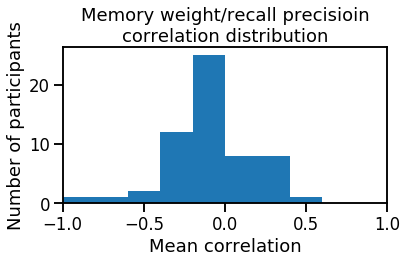

atlep1:
Ttest_1sampResult(statistic=-2.7614813234906816, pvalue=0.007729091635937598)
delayed
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58


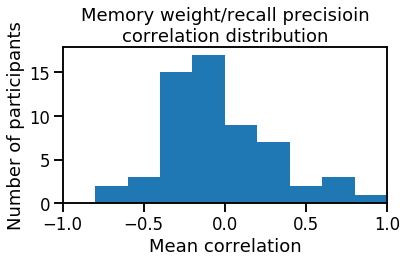

delayed:
Ttest_1sampResult(statistic=-0.7260551387809357, pvalue=0.4707248232650938)
atlep2
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


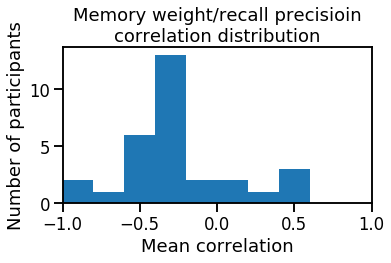

atlep2:
Ttest_1sampResult(statistic=-4.2080506750125, pvalue=0.00022678968374308217)
arrdev
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28


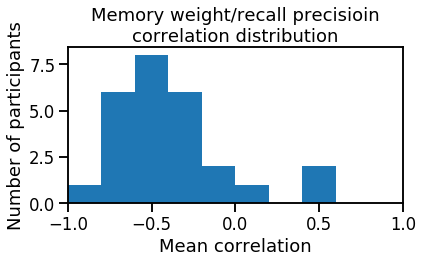

arrdev:
Ttest_1sampResult(statistic=-6.053095618108947, pvalue=2.524373006409756e-06)


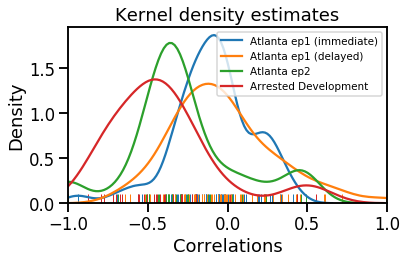

In [217]:
cs = []
memweight_precision_corrs = {'atlep1' : None, 'delayed' : None, 'atlep2' : None, 'arrdev' : None}


for rectype in ['atlep1','delayed','atlep2','arrdev']:
    print(rectype)

    atl1_rec_events = participant_events[rectype]
    atl1_matches = event_mappings[rectype]
    if rectype in ['atlep1', 'delayed']:
        atl1_events = episode_events['atlep1']
    else:
        atl1_events = episode_events[rectype]

    sub_corrs = np.zeros((len(atl1_rec_events),))

    for i, (tid, rec_events) in enumerate(atl1_rec_events):
        print(i)

        sub_matches = next(m for t, m in atl1_matches if t == tid)

        sub_precisions = np.zeros((np.unique(sub_matches.shape[0],)))
        sub_memweights = np.zeros((np.unique(sub_matches.shape[0],)))

        for ix, m in enumerate(np.unique(sub_matches)):
            rec_options = rec_events[np.where(sub_matches == m)]

            precision_opts = 1-cdist(np.atleast_2d(rec_options), np.atleast_2d(atl1_events[m]), 'correlation')
            precision = np.max(precision_opts)
            sub_precisions[ix] = _r2z(precision)
#             best_rec = rec_options[np.argmax(precision_opts)]
            
#             if rectype == 'delayed':
#                 e = 'atlep1'
#             else:
#                 e = rectype

#             r_event_voxweights = np.dot(best_rec, episode_topic_voxweights[e])
#             r_event_volume = cortex.Volume(r_event_voxweights, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
#             r_event_brainmap_mni = standardize_brainspace(r_event_volume)
            
#             r_event_volume.save_nii(os.path.join(braindata_dir, rectype, 'rec_events', 
#                                                  tid+'_event'+str(m)+'_volume.nii.gz'))
#             nb.save(r_event_brainmap_mni, os.path.join(braindata_dir, rectype, 'rec_events', 
#                                                        tid+'_event'+str(m)+'_mni.nii.gz'))

#             decoded_memweight = memory_decoder.decode(np.expand_dims(ns_dataset.masker.mask(r_event_brainmap_mni), 
#                                                                      axis=1))

            decoded_memweight = memory_decoder.decode(os.path.join(braindata_dir, rectype, 'pres_events', 
                                           tid+'_event'+str(m)+'_mni.nii.gz'))
    
            if decoded_memweight.values.ravel().shape[0] > 1:
                sub_memweights[ix] = _r2z(corr_mean(decoded_memweight.values.ravel()))
            else:
                sub_memweights[ix] = _r2z(decoded_memweight.values.ravel()[0])

        sub_corrs[i] = pearsonr(sub_memweights, sub_precisions)[0]
        
    memweight_precision_corrs[rectype] = sub_corrs
    sub_cs = sub_corrs[np.where(np.abs(sub_corrs) < 1)]
    cs.append(sub_cs)
  
    sns.set_context('talk')
    plt.hist(sub_cs, bins=10, range=(-1,1))
    plt.title('Memory weight/recall precisioin\ncorrelation distribution')
    plt.xlabel('Mean correlation')
    plt.ylabel('Number of participants')
    plt.xlim(-1,1)
    plt.tight_layout()
    plt.savefig(brainfig_dir+'{}_pres-memweight-complex-precision-distrib.pdf'.format(rectype))
    plt.show()
    print(rectype + ':')
    print(ttest_1samp(sub_cs, 0))
    
for ep_cs, ep_name in zip(cs, ['Atlanta ep1 (immediate)', 'Atlanta ep1 (delayed)', 'Atlanta ep2', 
                               'Arrested Development']):
    plt.xlim(-1,1)
    sns.distplot(ep_cs, bins=10, hist=False, kde=True, rug=True, label=ep_name)
plt.legend(fontsize='xx-small')
plt.title('Kernel density estimates')
plt.xlabel('Correlations')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig(brainfig_dir+'pres-memweight-complex-precision-kdes.pdf')

### memweight rec

atlep1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58


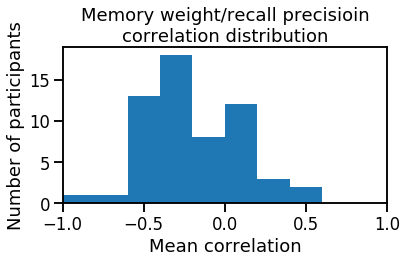

atlep1:
Ttest_1sampResult(statistic=-5.124149205818613, pvalue=3.7015225696602847e-06)
delayed
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58


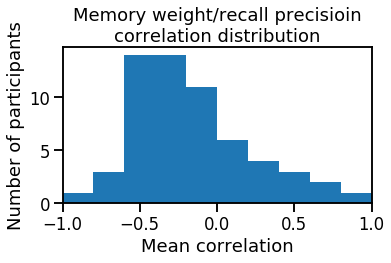

delayed:
Ttest_1sampResult(statistic=-3.2207965280083637, pvalue=0.002096929280677594)
atlep2
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


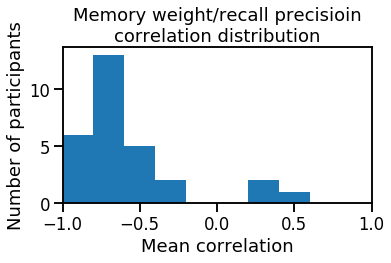

atlep2:
Ttest_1sampResult(statistic=-8.644458026129533, pvalue=2.1625241500157662e-09)
arrdev
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28


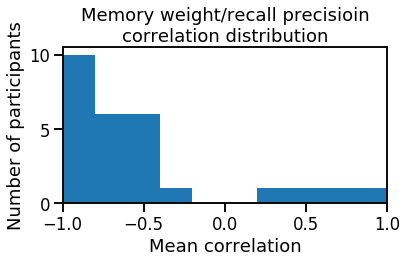

arrdev:
Ttest_1sampResult(statistic=-5.1163160800380805, pvalue=2.4729253685377626e-05)


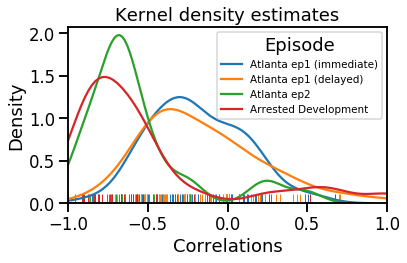

In [218]:
cs = []
memweight_precision_corrs = {'atlep1' : None, 'delayed' : None, 'atlep2' : None, 'arrdev' : None}


for rectype in ['atlep1','delayed','atlep2','arrdev']:
    print(rectype)

    atl1_rec_events = participant_events[rectype]
    atl1_matches = event_mappings[rectype]
    if rectype in ['atlep1', 'delayed']:
        atl1_events = episode_events['atlep1']
    else:
        atl1_events = episode_events[rectype]

    sub_corrs = np.zeros((len(atl1_rec_events),))

    for i, (tid, rec_events) in enumerate(atl1_rec_events):
        print(i)

        sub_matches = next(m for t, m in atl1_matches if t == tid)

        sub_precisions = np.zeros((np.unique(sub_matches.shape[0],)))
        sub_memweights = np.zeros((np.unique(sub_matches.shape[0],)))

        for ix, m in enumerate(np.unique(sub_matches)):
            rec_options = rec_events[np.where(sub_matches == m)]

            precision_opts = 1-cdist(np.atleast_2d(rec_options), np.atleast_2d(atl1_events[m]), 'correlation')
            precision = np.max(precision_opts)
            sub_precisions[ix] = _r2z(precision)
#             best_rec = rec_options[np.argmax(precision_opts)]
            
#             if rectype == 'delayed':
#                 e = 'atlep1'
#             else:
#                 e = rectype

#             r_event_voxweights = np.dot(best_rec, episode_topic_voxweights[e])
#             r_event_volume = cortex.Volume(r_event_voxweights, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
#             r_event_brainmap_mni = standardize_brainspace(r_event_volume)
            
#             r_event_volume.save_nii(os.path.join(braindata_dir, rectype, 'rec_events', 
#                                                  tid+'_event'+str(m)+'_volume.nii.gz'))
#             nb.save(r_event_brainmap_mni, os.path.join(braindata_dir, rectype, 'rec_events', 
#                                                        tid+'_event'+str(m)+'_mni.nii.gz'))

#             decoded_memweight = memory_decoder.decode(np.expand_dims(ns_dataset.masker.mask(r_event_brainmap_mni), 
#                                                                      axis=1))

            decoded_memweight = memory_decoder.decode(os.path.join(braindata_dir, rectype, 'rec_events', 
                                           tid+'_event'+str(m)+'_mni.nii.gz'))
    
            if decoded_memweight.values.ravel().shape[0] > 1:
                sub_memweights[ix] = _r2z(corr_mean(decoded_memweight.values.ravel()))
            else:
                sub_memweights[ix] = _r2z(decoded_memweight.values.ravel()[0])

        sub_corrs[i] = pearsonr(sub_memweights, sub_precisions)[0]
        
    memweight_precision_corrs[rectype] = sub_corrs
    sub_cs = sub_corrs[np.where(np.abs(sub_corrs) < 1)]
    cs.append(sub_cs)
  
    sns.set_context('talk')
    plt.hist(sub_cs, bins=10, range=(-1,1))
    plt.title('Memory weight/recall precisioin\ncorrelation distribution')
    plt.xlabel('Mean correlation')
    plt.ylabel('Number of participants')
    plt.xlim(-1,1)
    plt.tight_layout()
    plt.savefig(brainfig_dir+'{}_memweight-complex-precision-distrib.pdf'.format(rectype))
    plt.show()
    print(rectype + ':')
    print(ttest_1samp(sub_cs, 0))
    
for ep_cs, ep_name in zip(cs, ['Atlanta ep1 (immediate)', 'Atlanta ep1 (delayed)', 'Atlanta ep2', 
                               'Arrested Development']):
    plt.xlim(-1,1)
    sns.distplot(ep_cs, bins=10, hist=False, kde=True, rug=True, label=ep_name)
plt.legend(title='Episode', loc=0, fontsize='xx-small')
plt.title('Kernel density estimates')
plt.xlabel('Correlations')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig(brainfig_dir+'memweight-complex-precision-kdes.pdf')

In [219]:
ttest_rel(_r2z(np.delete(cs[1], 29)), _r2z(cs[0]))

Ttest_relResult(statistic=0.9495008586945057, pvalue=0.3463745316397543)

In [5]:
dmn_decoder = ns.analysis.decode.Decoder(ns_dataset, features=['default mode', 'precuneus', 'default', 'mode network',
                                                              'posterior cingulate'])

In [10]:
len(ns_dataset.get_studies(features=['default mode', 'precuneus', 'default', 'mode network','posterior cingulate']))

2249

In [8]:
dmn_decoder.

array([[ 0.5784126 , -0.95973102,  0.22148347,  0.98408033,  1.07405787],
       [-0.41573894, -0.90725224, -0.69865186, -0.10123519,  0.66993603],
       [-0.28275189, -1.74096585, -0.5635689 ,  0.03046819,  0.35912775],
       ...,
       [ 1.21048255, -0.99218298,  1.40493905,  0.97679249, -1.42901879],
       [ 0.20440567, -1.30420437,  0.8920596 , -0.02337913, -1.68557561],
       [ 0.77074595, -0.87561313,  0.45067132,  1.13655677, -1.33476126]])

### dmnweight pres

atlep1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58


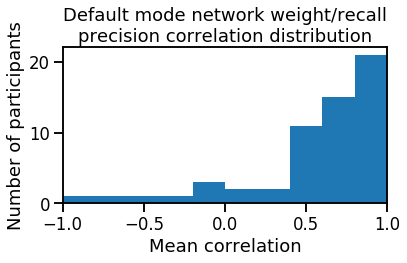

atlep1:
Ttest_1sampResult(statistic=10.157429701221417, pvalue=2.1146533202732954e-14)
delayed
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58


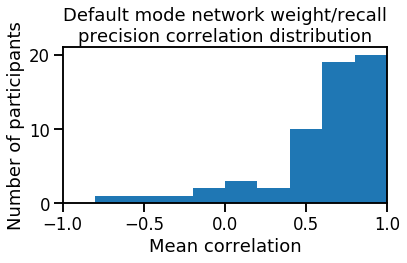

delayed:
Ttest_1sampResult(statistic=12.92412801328511, pvalue=1.0112622253940108e-18)
atlep2
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


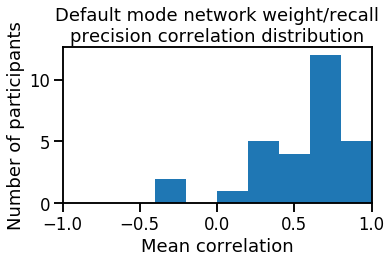

atlep2:
Ttest_1sampResult(statistic=8.951242062520768, pvalue=1.0468782005694686e-09)
arrdev
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28


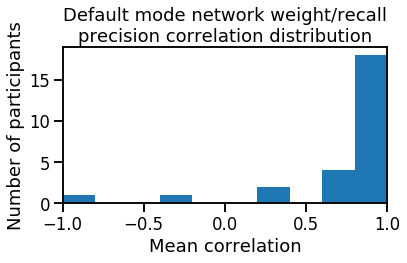

arrdev:
Ttest_1sampResult(statistic=8.451351521260682, pvalue=8.515040956004446e-09)


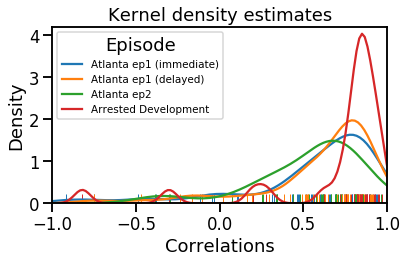

In [224]:
cs = []
dmnweight_precision_corrs = {'atlep1' : None, 'delayed' : None, 'atlep2' : None, 'arrdev' : None}

for rectype in ['atlep1','delayed','atlep2','arrdev']:
    print(rectype)

    atl1_rec_events = participant_events[rectype]
    atl1_matches = event_mappings[rectype]
    if rectype in ['atlep1', 'delayed']:
        atl1_events = episode_events['atlep1']
    else:
        atl1_events = episode_events[rectype]

    sub_corrs = np.zeros((len(atl1_rec_events),))

    for i, (tid, rec_events) in enumerate(atl1_rec_events):
        print(i)

        sub_matches = next(m for t, m in atl1_matches if t == tid)

        sub_precisions = np.zeros((np.unique(sub_matches.shape[0],)))
        sub_dmnweights = np.zeros((np.unique(sub_matches.shape[0],)))

        for ix, m in enumerate(np.unique(sub_matches)):
            rec_options = rec_events[np.where(sub_matches == m)]

            precision_opts = 1-cdist(np.atleast_2d(rec_options), np.atleast_2d(atl1_events[m]), 'correlation')
            precision = np.max(precision_opts)
            sub_precisions[ix] = _r2z(precision)
#             best_rec = rec_options[np.argmax(precision_opts)]
            
#             if rectype == 'delayed':
#                 e = 'atlep1'
#             else:
#                 e = rectype

#             p_event_voxweights = np.dot(atl1_events[m], episode_topic_voxweights[e])
#             p_event_volume = cortex.Volume(p_event_voxweights, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
#             p_event_brainmap_mni = standardize_brainspace(p_event_volume)
            
#             p_event_volume.save_nii(os.path.join(braindata_dir, rectype, 'pres_events', 
#                                                  tid+'_event'+str(m)+'_volume.nii.gz'))
#             nb.save(p_event_brainmap_mni, os.path.join(braindata_dir, rectype, 'pres_events', 
#                                                        tid+'_event'+str(m)+'_mni.nii.gz'))

            decoded_dmnweight = dmn_decoder.decode(os.path.join(braindata_dir, rectype, 'pres_events', 
                                                       tid+'_event'+str(m)+'_mni.nii.gz'))
#             decoded_dmnweight = dmn_decoder.decode(np.expand_dims(ns_dataset.masker.mask(p_event_brainmap_mni), 
#                                                                      axis=1))
    
            if decoded_dmnweight.values.ravel().shape[0] > 1:
                sub_dmnweights[ix] = _r2z(corr_mean(decoded_dmnweight.values.ravel()))
            else:
                sub_dmnweights[ix] = _r2z(decoded_dmnweight.values.ravel()[0])

        sub_corrs[i] = pearsonr(sub_dmnweights, sub_precisions)[0]
        
    dmnweight_precision_corrs[rectype] = sub_corrs
    sub_cs = sub_corrs[np.where(np.abs(sub_corrs) < 1)]
    cs.append(sub_cs)

    sns.set_context('talk')
    plt.hist(sub_cs, bins=10, range=(-1,1))
    plt.title('Default mode network weight/recall\nprecision correlation distribution')
    plt.xlabel('Mean correlation')
    plt.ylabel('Number of participants')
    plt.xlim(-1,1)
    plt.tight_layout()
    plt.savefig(brainfig_dir+'{}_pres-dmnweight-precision-distrib.pdf'.format(rectype))
    plt.show()
    print(rectype + ':')
    print(ttest_1samp(sub_cs, 0))
    
    
for ep_cs, ep_name in zip(cs, ['Atlanta ep1 (immediate)', 'Atlanta ep1 (delayed)', 'Atlanta ep2', 
                               'Arrested Development']):
    plt.xlim(-1,1)
    plt.ylim(0,4.2)
    sns.distplot(ep_cs, bins=10, hist=False, kde=True, rug=True, label=ep_name)
plt.legend(title='Episode', loc=0, fontsize='xx-small')
plt.title('Kernel density estimates')
plt.xlabel('Correlations')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig(brainfig_dir+'pres-dmnweight-precision-kdes.pdf')

## dmnweight rec

atlep1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58


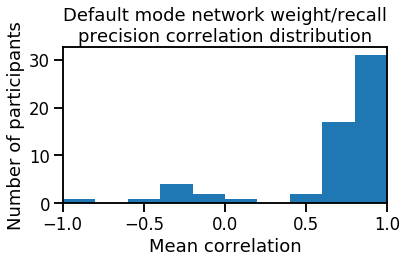

atlep1:
Ttest_1sampResult(statistic=11.269182848001343, pvalue=3.0803578253061845e-16)
delayed
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58


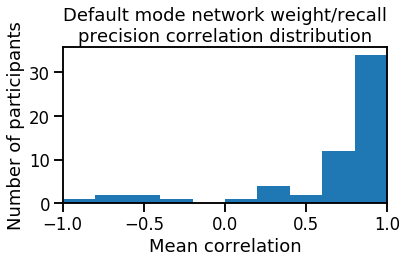

delayed:
Ttest_1sampResult(statistic=10.455783735784056, pvalue=5.7980416910136345e-15)
atlep2
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


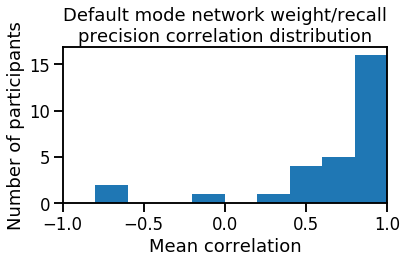

atlep2:
Ttest_1sampResult(statistic=7.781194135063825, pvalue=1.779647932183299e-08)
arrdev
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28


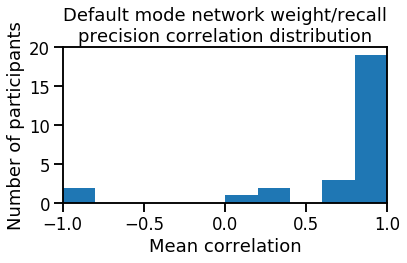

arrdev:
Ttest_1sampResult(statistic=6.430969176024912, pvalue=8.176208668149594e-07)


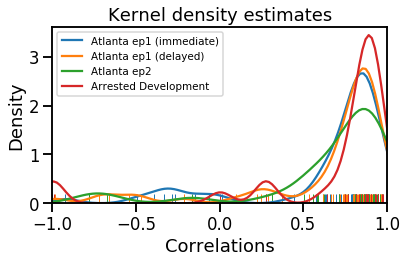

In [223]:
cs = []
dmnweight_precision_corrs = {'atlep1' : None, 'delayed' : None, 'atlep2' : None, 'arrdev' : None}

for rectype in ['atlep1','delayed','atlep2','arrdev']:
    print(rectype)

    atl1_rec_events = participant_events[rectype]
    atl1_matches = event_mappings[rectype]
    if rectype in ['atlep1', 'delayed']:
        atl1_events = episode_events['atlep1']
    else:
        atl1_events = episode_events[rectype]

    sub_corrs = np.zeros((len(atl1_rec_events),))

    for i, (tid, rec_events) in enumerate(atl1_rec_events):
        print(i)

        sub_matches = next(m for t, m in atl1_matches if t == tid)

        sub_precisions = np.zeros((np.unique(sub_matches.shape[0],)))
        sub_dmnweights = np.zeros((np.unique(sub_matches.shape[0],)))

        for ix, m in enumerate(np.unique(sub_matches)):
            rec_options = rec_events[np.where(sub_matches == m)]

            precision_opts = 1-cdist(np.atleast_2d(rec_options), np.atleast_2d(atl1_events[m]), 'correlation')
            precision = np.max(precision_opts)
            sub_precisions[ix] = _r2z(precision)
#             best_rec = rec_options[np.argmax(precision_opts)]
          
#             if rectype == 'delayed':
#                 e = 'atlep1'
#             else:
#                 e = rectype

#             p_event_voxweights = np.dot(atl1_events[m], episode_topic_voxweights[e])
#             p_event_volume = cortex.Volume(p_event_voxweights, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
#             p_event_brainmap_mni = standardize_brainspace(p_event_volume)
            
#             p_event_volume.save_nii(os.path.join(braindata_dir, rectype, 'pres_events', 
#                                                  tid+'_event'+str(m)+'_volume.nii.gz'))
#             nb.save(p_event_brainmap_mni, os.path.join(braindata_dir, rectype, 'pres_events', 
#                                                        tid+'_event'+str(m)+'_mni.nii.gz'))

            decoded_dmnweight = dmn_decoder.decode(os.path.join(braindata_dir, rectype, 'rec_events', 
                                                       tid+'_event'+str(m)+'_mni.nii.gz'))
#             decoded_dmnweight = dmn_decoder.decode(np.expand_dims(ns_dataset.masker.mask(p_event_brainmap_mni), 
#                                                                      axis=1))
    
            if decoded_dmnweight.values.ravel().shape[0] > 1:
                sub_dmnweights[ix] = _r2z(corr_mean(decoded_dmnweight.values.ravel()))
            else:
                sub_dmnweights[ix] = _r2z(decoded_dmnweight.values.ravel()[0])

        sub_corrs[i] = pearsonr(sub_dmnweights, sub_precisions)[0]
        
    dmnweight_precision_corrs[rectype] = sub_corrs
    sub_cs = sub_corrs[np.where(np.abs(sub_corrs) < 1)]
    cs.append(sub_cs)

    
    plt.hist(sub_cs, bins=10, range=(-1,1))
    plt.title('Default mode network weight/recall\nprecision correlation distribution')
    plt.xlabel('Mean correlation')
    plt.ylabel('Number of participants')
    plt.xlim(-1,1)
    plt.tight_layout()
    plt.savefig(brainfig_dir+'{}_dmnweight-precision-distrib.pdf'.format(rectype))
    plt.show()
    print(rectype + ':')
    print(ttest_1samp(sub_cs, 0))
    
    
sns.set_context('talk')    
for ep_cs, ep_name in zip(cs, ['Atlanta ep1 (immediate)', 'Atlanta ep1 (delayed)', 'Atlanta ep2', 
                               'Arrested Development']):
    plt.xlim(-1,1)
#     plt.ylim(0,4.2)
    sns.distplot(ep_cs, bins=10, hist=False, kde=True, rug=True, label=ep_name)
plt.legend(fontsize='xx-small')
plt.title('Kernel density estimates')
plt.xlabel('Correlations')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig(brainfig_dir+'dmnweight-precision-kdes.pdf')

In [222]:
ttest_rel(_r2z(cs[1]), _r2z(cs[0]))

Ttest_relResult(statistic=-0.9336159932016006, pvalue=0.3543725914124565)

In [199]:
dmn_data = ns_dataset.get_studies(features=['default mode', 'precuneus', 'default', 'mode network', 
                                                 'posterior cingulate'])
dmn_data = ns_dataset.get_image_data(dmn_data).T

In [200]:
mem_data = ns_dataset.get_studies(features=['memory','hippocampus','encoding','retrieval', 'medial temporal'])
mem_data = ns_dataset.image_table.get_image_data(mem_data).T

In [ ]:
del dmn_data
del mem_data

In [193]:
pearsonr(_r2z(dmn_data), _r2z(mem_data))

(nan, 1.0)